![QuantConnect Logo](https://cdn.quantconnect.com/web/i/icon.png)
<hr>

## Quiver Insider Trading Research

This notebook studies whether insider dollar volume helps explain future returns

In [1]:
qb = QuantBook()
# Anchor the research clock to the start of 2026.
qb.set_start_date(2026, 1, 1)
# Daily bars will have an end_time that matches the following midnight.
qb.settings.daily_precise_end_time = False

### Build an Insider Trading Universe

Select the 10 assets with the largest insider-trading dollar volume each day, then inspect the returned universe history.

In [2]:
def select_assets(data: List[QuiverInsiderTradingUniverse]) -> List[Symbol]:
    # Aggregate insider dollar volume per ticker and keep the 10 largest.
    dollar_volume: dict[Symbol, float] = {}
    for d in data:
        if not d.price_per_share:
            continue
        dollar_volume[d.symbol] = dollar_volume.get(d.symbol, 0) + (d.shares or 0) * d.price_per_share
    return [s for s, _ in sorted(dollar_volume.items(), key=lambda kv: kv[1])[-10:]]

# Add the Quiver Insider Trading universe.
universe = qb.add_universe(QuiverInsiderTradingUniverse, select_assets)
# Request universe history of the last 30 days.
universe_history = qb.universe_history(universe, qb.time - timedelta(30), qb.time - timedelta(1), flatten=True)
# Print the returned shape and columns.
print(f"Shape: {universe_history.shape}")
print(f"Columns: {list(universe_history.columns)}")
universe_history.head()

Shape: (290, 15)
Columns: ['acquireddisposedcode', 'date', 'directorindirectownership', 'filedate', 'isdirector', 'isofficer', 'istenpercentowner', 'name', 'officertitle', 'pricepershare', 'shares', 'sharesownedfollowing', 'transactioncode', 'value', 'isother']


acquireddisposedcode       date  \
time       symbol                                              
2025-12-03 CRM SZQUJUA9SVOL              Acquired 2025-12-02   
           CVNA WK2S2IM8SSPX             Disposed 2025-12-01   
           FLS R735QTJ8XC9X              Acquired 2025-12-02   
           GPOR XOL14ZD845ET             Disposed 2025-12-01   
           HOOD XQJXBPPDMGYT             Disposed 2025-12-01   

                             directorindirectownership            filedate  \
time       symbol                                                            
2025-12-03 CRM SZQUJUA9SVOL                     Direct 2025-12-02 00:00:00   
           CVNA WK2S2IM8SSPX                    Direct 2025-12-01 23:50:59   
           FLS R735QTJ8XC9X                     Direct 2025-12-02 00:00:00   
           GPOR XOL14ZD845ET                    Direct 2025-12-02 00:00:00   
           HOOD XQJXBPPDMGYT                    Direct 2025-12-02 00:00:00   

                             isdirector isofficer istenpercentowner  \
time       symbol                                                     
2025-12-03 CRM SZQUJUA9SVOL        True      True              None   
           CVNA WK2S2IM8SSPX      False      True             False   
           FLS R735QTJ8XC9X        True      True             False   
           GPOR XOL14ZD845ET       True     False              True   
           HOOD XQJXBPPDMGYT      False      True             False   

                                                   name  \
time       symbol                                         
2025-12-03 CRM SZQUJUA9SVOL               Harris Parker   
           CVNA WK2S2IM8SSPX         HUSTON BENJAMIN E.   
           FLS R735QTJ8XC9X           Rowe Robert Scott   
           GPOR XOL14ZD845ET  Silver Point Capital L.P.   
           HOOD XQJXBPPDMGYT            Quirk Steven M.   

                                          officertitle  pricepershare  \
time       symbol                                                       
2025-12-03 CRM SZQUJUA9SVOL   Co-Founder and CTO Slack         161.50   
           CVNA WK2S2IM8SSPX   Chief Operating Officer         375.26   
           FLS R735QTJ8XC9X            President & CEO          48.63   
           GPOR XOL14ZD845ET                                   219.56   
           HOOD XQJXBPPDMGYT   Chief Brokerage Officer         128.49   

                                shares  sharesownedfollowing  \
time       symbol                                              
2025-12-03 CRM SZQUJUA9SVOL   134662.0              274429.0   
           CVNA WK2S2IM8SSPX    1219.0              100758.0   
           FLS R735QTJ8XC9X   114943.0              559313.0   
           GPOR XOL14ZD845ET  244489.0             3495431.0   
           HOOD XQJXBPPDMGYT   27172.0              104438.0   

                                            transactioncode   value isother  
time       symbol                                                            
2025-12-03 CRM SZQUJUA9SVOL      ExerciseOrConversionExempt  161.50     NaN  
           CVNA WK2S2IM8SSPX  ExercisePaymentWithSecurities  375.26     NaN  
           FLS R735QTJ8XC9X      ExerciseOrConversionExempt   48.63     NaN  
           GPOR XOL14ZD845ET                           Sale  219.56     NaN  
           HOOD XQJXBPPDMGYT  ExercisePaymentWithSecurities  128.49     NaN

### Universe Diagnostics

Derive each trade's dollar volume, then inspect its distribution and visualize how the daily universe size evolves chronologically.

Universe days: 29
Mean basket size per day: 10.0

count           290.000
mean       28533000.898
std       227077018.571
min               0.000
25%           92346.368
50%         1907853.085
75%         8149776.770
max      3765636073.000
Name: dollarvolume, dtype: object


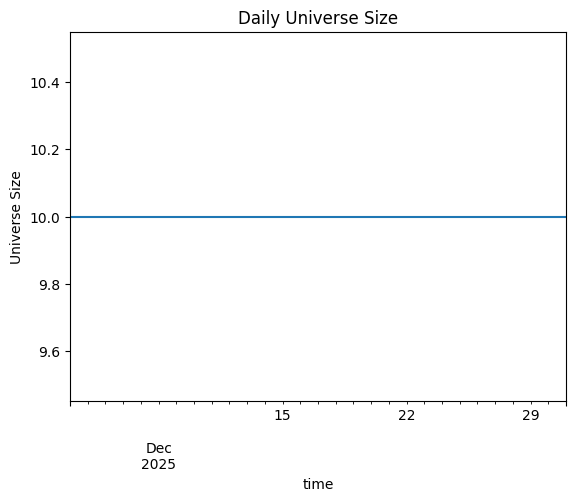

In [3]:
# Derive each insider trade's dollar volume from shares and price per share.
universe_history['dollarvolume'] = universe_history['shares'].fillna(0) * universe_history['pricepershare'].fillna(0)
# Count selected assets by day.
universe_size = universe_history.reset_index().groupby(['time', 'symbol']).count().dollarvolume.groupby(level=0).count()
print(f"Universe days: {len(universe_size)}")
# Store the selected symbol list.
unique_assets = list(universe_history.index.levels[1].unique())
print(f"Mean basket size per day: {universe_size.mean():.1f}")
print('')
print(universe_history.dollarvolume.describe().map('{:0.3f}'.format))
universe_size.plot(title='Daily Universe Size', ylabel='Universe Size');

### Daily Universe Prices

Fetch daily price history for every symbol that appears in the universe.

In [4]:
# Extract unique assets
symbols = list(universe_history.index.get_level_values(1).unique())
# Fetch daily historical price metrics using the earliest timestamp available in the index.
history = qb.history(symbols, universe_history.index[0][0] - timedelta(1), qb.time, Resolution.DAILY)
history

close        high         low        open  \
symbol            time                                                         
CRM SZQUJUA9SVOL  2025-12-03  233.747149  235.619437  230.669825  232.064082   
                  2025-12-04  237.740699  238.248607  232.253303  234.394483   
                  2025-12-05  246.444845  247.918773  236.625294  242.999039   
                  2025-12-06  259.501064  260.805690  248.566107  249.801020   
                  2025-12-09  258.465330  263.185885  255.368088  260.805690   
...                                  ...         ...         ...         ...   
MDLN YYDBHHPS742T 2025-12-25   44.280000   45.010000   43.550000   43.950000   
                  2025-12-27   44.085000   45.450000   43.610000   44.500000   
                  2025-12-30   42.090000   43.800000   41.735000   43.570000   
                  2025-12-31   41.820000   43.250000   41.620000   42.050000   
                  2026-01-01   42.000000   43.070000   41.210000   41.940000   

                                  volume  
symbol            time                    
CRM SZQUJUA9SVOL  2025-12-03   6564561.0  
                  2025-12-04   9868516.0  
                  2025-12-05  18417875.0  
                  2025-12-06  15131428.0  
                  2025-12-09   9563168.0  
...                                  ...  
MDLN YYDBHHPS742T 2025-12-25   4363660.0  
                  2025-12-27   8118252.0  
                  2025-12-30   5517778.0  
                  2025-12-31   4102917.0  
                  2026-01-01   5587994.0  

[3209 rows x 5 columns]

### Align Insider Volume And Returns

Build a joined table of insider dollar volume and future returns.

In [5]:
dataset = (
    universe_history.reset_index().groupby(['time', 'symbol']).agg(dollarvolume=('dollarvolume', 'sum'))
    .join(history.open.unstack('symbol').sort_index().pct_change(2, fill_method=None).shift(-2).stack().rename('futurereturn').rename_axis(['time','symbol']), how='inner')
)
dataset.head()

dollarvolume  futurereturn
time       symbol                                       
2025-12-03 TASR S5BXFVIKPX7P     622256.07      0.015856
           CRM SZQUJUA9SVOL    21747913.00      0.047120
           CVNA WK2S2IM8SSPX     457441.94      0.047844
           FLS R735QTJ8XC9X     5589678.09     -0.002949
           GPOR XOL14ZD845ET   53680004.84     -0.021170

### Analyze Relationships Between Factor and Future Returns

Drop the 1% outliers on each side of the factor and fit a line of best fit.

Factor: dollarvolume
Observations: 178
Mean future return: 0.05%
Alpha: -0.01%
Beta: 0.00%
R-squared: 0.08%


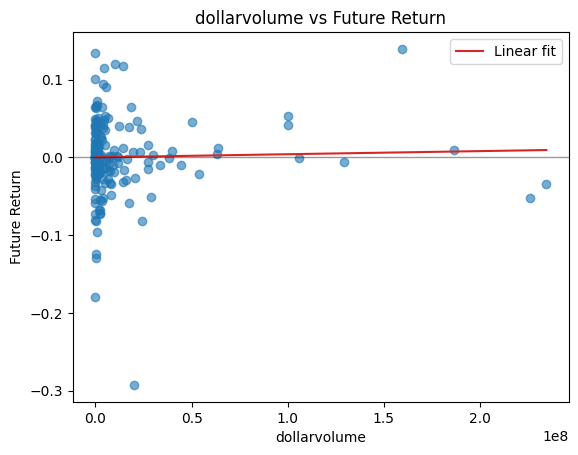

In [6]:
factor = 'dollarvolume'
# Assign the factor values.
x = dataset[factor]
y = dataset['futurereturn']
# Drop the 1% outliers on each side of the factor.
lower, upper = x.quantile([0.01, 0.99])
mask = x.between(lower, upper)
x, y = x[mask], y[mask]
# Fit a simple linear model.
slope, intercept = np.polyfit(x, y, 1)
r_squared = x.corr(y) ** 2
# Print the linear model statistics.
print(f"Factor: {factor}")
print(f"Observations: {len(x)}")
print(f"Mean future return: {y.mean():.2%}")
print(f"Alpha: {intercept:.2%}")
print(f"Beta: {slope:.2%}")
print(f"R-squared: {r_squared:.2%}")
# Plot the factor values against future returns.
plt.scatter(x, y, alpha=0.6)
plt.plot(x.sort_values(), intercept + slope * x.sort_values(), color='tab:red', label='Linear fit')
plt.axhline(0, color='black', linewidth=1, alpha=0.4)
plt.title(f'{factor} vs Future Return')
plt.xlabel(factor)
plt.ylabel('Future Return')
plt.legend()
plt.show()

Create a box plot of dollar-volume quantile buckets compared to future returns.

Factor: dollarvolume


,bucket,mean_factor,min_future_return,max_future_return,mean_future_return,std_future_return,observations
0,"(-0.001, 625.616]",0.000,-17.98%,13.39%,-0.42%,4.95%,36
1,"(625.616, 721921.15]",228852.467,-12.95%,10.03%,0.26%,5.07%,35
2,"(721921.15, 3943568.38]",2047853.945,-7.35%,7.23%,-0.51%,3.65%,36
3,"(3943568.38, 14298351.01]",7197516.624,-5.18%,11.94%,1.22%,4.35%,35
4,"(14298351.01, 234466424.082]",56940884.839,-29.27%,13.93%,-0.28%,6.67%,36


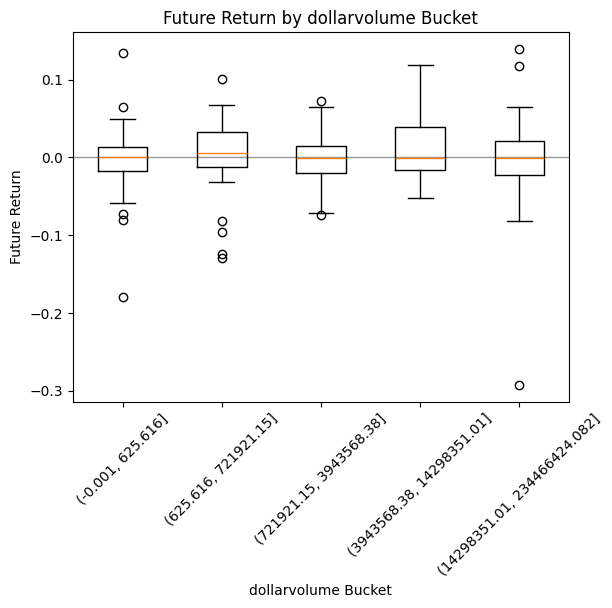

In [7]:
# Split factor values into quantile buckets.
buckets = pd.qcut(x, q=5, duplicates='drop')
# Summarize each bucket with distribution statistics.
summary = dataset.assign(bucket=buckets).groupby('bucket', observed=True).agg(
    mean_factor=(factor, 'mean'),
    min_future_return=('futurereturn', 'min'),
    max_future_return=('futurereturn', 'max'),
    mean_future_return=('futurereturn', 'mean'),
    std_future_return=('futurereturn', 'std'),
    observations=('futurereturn', 'size')
).reset_index()
summary['bucket'] = summary['bucket'].astype(str)
# Display the bucket summary.
print(f"Factor: {factor}")
display(summary.style.format({
    'mean_factor': '{:.3f}',
    'min_future_return': '{:.2%}',
    'max_future_return': '{:.2%}',
    'mean_future_return': '{:.2%}',
    'std_future_return': '{:.2%}'
}))
# Plot the return distribution for each bucket.
groups = [y[buckets == b].values for b in buckets.cat.categories]
plt.boxplot(groups, labels=[str(b) for b in buckets.cat.categories])
plt.axhline(0, color='black', linewidth=1, alpha=0.4)
plt.title(f'Future Return by {factor} Bucket')
plt.xlabel(f'{factor} Bucket')
plt.ylabel('Future Return')
plt.xticks(rotation=45)
plt.show()